<a href="https://colab.research.google.com/github/akb22ee015/akb22ee015/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!git clone 'https://github.com/rheadoshi/PRML'

fatal: destination path 'PRML' already exists and is not an empty directory.


In [ ]:
dataset = pd.read_csv('/content/PRML/healthcare-dataset-stroke-data.csv')
dataset.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Exploratory Data Analysis

In [ ]:
dataset.shape

(5110, 12)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


## Filling missing data

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


We can see some data is missing for bmi feature. So to fill in the that data, we can find average value of bmi grouping them by gender and age.  


In [ ]:
# Creating a new column 'Age_class' based on age ranges
dataset['Age_class'] = dataset['age'].apply(lambda x: 1 if x < 25 else (2 if x < 50 else 3))


In [ ]:
print((dataset.groupby(['gender', 'Age_class'])['bmi'].agg(['mean'])))

                       mean
gender Age_class           
Female 1          23.714660
       2          30.653965
       3          30.568066
Male   1          22.603565
       2          31.305913
       3          30.776571
Other  2          22.400000


In [ ]:
dataset["bmi"] = dataset["bmi"].fillna(-1)
for i in range(dataset.shape[0]):
  if dataset.loc[i,'bmi']==-1:
    if dataset.loc[i,'Age_class']==1:
      if dataset.loc[i,'gender']=='Female':
        dataset.loc[i,'bmi']=23.71
      else:
        dataset.loc[i,'bmi']=22.60
    elif dataset.loc[i,'Age_class']==3:
      if dataset.loc[i,'gender']=='Female':
        dataset.loc[i,'bmi']=30.57
      else:
        dataset.loc[i,'bmi']=30.78
    else:
      if dataset.loc[i,'gender']=='Female':
        dataset.loc[i,'bmi']=30.65
      elif dataset.loc[i,'gender']=='Male':
        dataset.loc[i,'bmi']=31.31
      else:
        dataset.loc[i,'bmi']=22.4

In [ ]:
dataset.drop(columns=['Age_class'],inplace = True)
print(((dataset.isna().sum())/dataset.shape[0])*100)


id                   0.0
gender               0.0
age                  0.0
hypertension         0.0
heart_disease        0.0
ever_married         0.0
work_type            0.0
Residence_type       0.0
avg_glucose_level    0.0
bmi                  0.0
smoking_status       0.0
stroke               0.0
dtype: float64


Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
cols = ['gender', 'ever_married', 'work_type', 'Residence_type','smoking_status','stroke']
le = LabelEncoder()
for col in cols:
    dataset.loc[:,col] = le.fit_transform(dataset.loc[:,col])
    dataset[col] = dataset[col].astype(int)
dataset=dataset.drop(columns=['id'])
dataset.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.60,1,1
1,0,61.0,0,0,1,3,0,202.21,30.57,2,1
2,1,80.0,0,1,1,2,0,105.92,32.50,2,1
3,0,49.0,0,0,1,2,1,171.23,34.40,3,1
4,0,79.0,1,0,1,3,0,174.12,24.00,2,1


## Handling Outliers

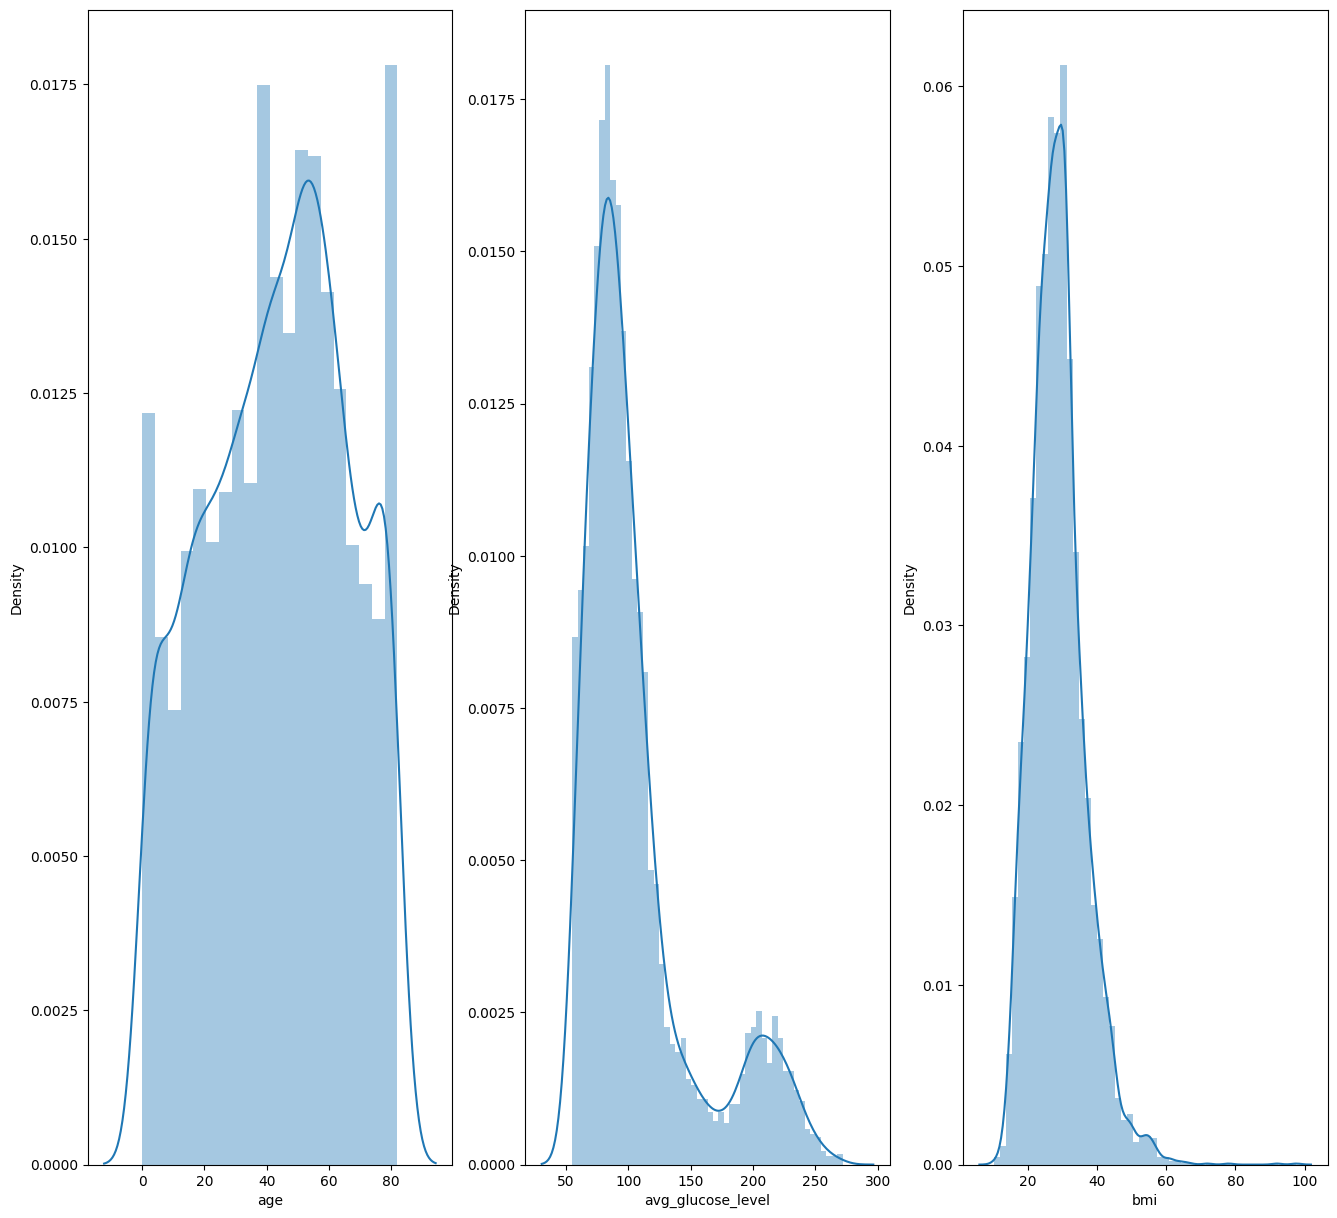

In [ ]:
## Numerical columns -> age, avg_glucose_level, bmi
plt.figure(figsize=(16,15))
plt.subplot(1,3,1)
sns.distplot(dataset['age'])

plt.subplot(1,3,2)
sns.distplot(dataset['avg_glucose_level'])

plt.subplot(1,3,3)
sns.distplot(dataset['bmi'])

plt.show()

<Axes: ylabel='age'>

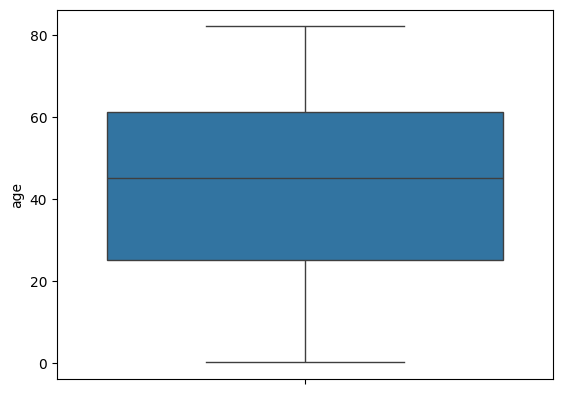

In [ ]:
sns.boxplot(dataset['age'])

<Axes: ylabel='avg_glucose_level'>

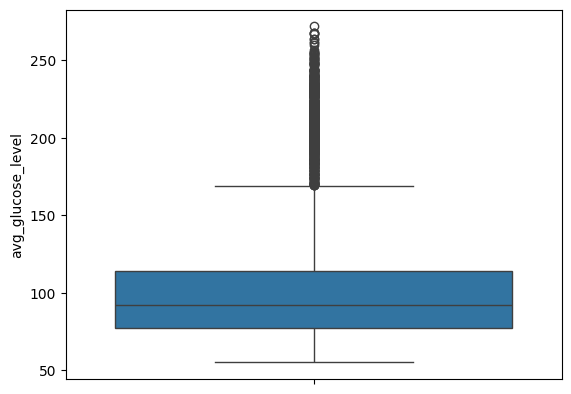

In [ ]:
sns.boxplot(dataset['avg_glucose_level'])

<Axes: ylabel='bmi'>

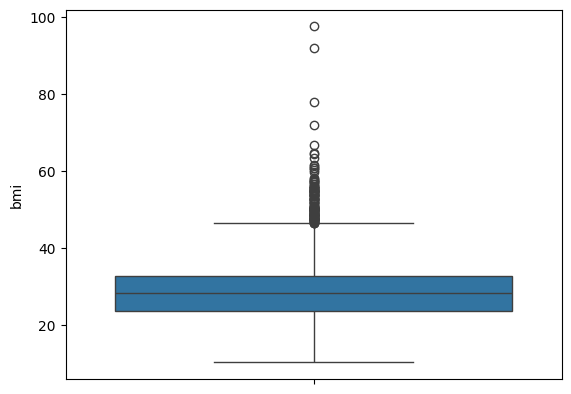

In [ ]:
sns.boxplot(dataset['bmi'])

We can observe that age feature does not contain any outliers. To handle the outliers in other two features, avg_glucose_level and bmi ?????

# Visualisation

# Splitting dataset

In [ ]:
X=dataset.drop(columns=['stroke'])
y=dataset['stroke']

x_train,x_test,y_train,y_test=train_test_split(X,y,train_size=0.7,random_state=42)


# Machine Learning Algorithms

## Decision Tree

In [ ]:
class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def calculate_entropy(self,col):
      data, counts = np.unique(col, return_counts=True)
      N = int(col.shape[0])

      entropy = 0.0

      for count in counts:
        p = count / N
        entropy += p * np.log2(p)

      return -entropy

    def information_gain(self,y, y_left, y_right):
      parent_entropy = self.calculate_entropy(y)
      left_weight = len(y_left) / len(y)
      right_weight = len(y_right) / len(y)
      child_entropy = left_weight * self.calculate_entropy(y_left) + right_weight * self.calculate_entropy(y_right)
      return parent_entropy - child_entropy

    def _build_tree(self, X, y, depth):
        if depth == self.max_depth or len(set(y)) == 1:
            # If max depth reached or pure node ==> leaf node
            return {'class': max(set(y), key=y.tolist().count), 'is_leaf': True}

        best_split_attribute, best_split_value = self._get_best_split(X, y)

        if best_split_attribute is None:
            # information gain = 0 ==>leaf node
            return {'class': max(set(y), key=y.tolist().count), 'is_leaf': True}

        left_indices = X[best_split_attribute] == best_split_value
        right_indices = ~left_indices

        if len(left_indices) == 0 or len(right_indices) == 0:
            # If a split=empty subset ==>leaf node
            return {'class': max(set(y), key=y.tolist().count), 'is_leaf': True}

        left_subtree = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_subtree = self._build_tree(X[right_indices], y[right_indices], depth + 1)

        return {
            'attribute': best_split_attribute,
            'value': best_split_value,
            'left': left_subtree,
            'right': right_subtree,
            'is_leaf': False
        }

    def _get_best_split(self, X, y):
        best_information_gain = 0
        best_split_attribute = None
        best_split_value = None

        for feature in X.columns:
            categories = X[feature].unique()
            for category in categories:
                left_indices = X[feature] == category
                right_indices = ~left_indices

                y_left, y_right = y[left_indices], y[right_indices]
                current_information_gain = self.information_gain(y, y_left, y_right)

                if current_information_gain > best_information_gain:
                    best_information_gain = current_information_gain
                    best_split_attribute = feature
                    best_split_value = category

        return best_split_attribute, best_split_value

    def predict(self, X):
        if self.tree is None:
            raise ValueError("The decision tree has not been fitted yet.")

        return np.array([self._traverse_tree(x, self.tree) for _, x in X.iterrows()])

    def _traverse_tree(self, sample, node):
        while not node['is_leaf']:
            attribute = node['attribute']
            value = node['value']

            if sample[attribute] == value:
                node = node['left']
            else:
                node = node['right']

        return node['class']


In [ ]:
dt = DecisionTree(max_depth=3)
dt.fit(x_train, y_train)

y_predicted=dt.predict(x_test)

accuracy = accuracy_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)
f1 = f1_score(y_test, y_predicted)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9803921568627451
Precision: 0.0
Recall: 0.0
F1-score: 0.0


## KNN

In [ ]:
class KNN():
    def __init__(self, k):
        self.k = k

    def fit(self, X_train, y_train):
        self.x_train = X_train
        self.y_train = y_train

    def calculate_euclidean(self, sample1, sample2):
        distance = 0.0
        for i in range(len(sample1)):
            distance += (sample1[i] - sample2[i]) ** 2
        return (distance) ** (1 / 2)

    def nearest_neighbors(self, test_sample):
        distances = []
        for i in range(len(self.x_train)):
            distances.append((self.y_train.iloc[i], self.calculate_euclidean(self.x_train.iloc[i], test_sample)))
        distances.sort(key=lambda x: x[1])
        neighbors = []
        for i in range(self.k):
            neighbors.append(distances[i][0])
        return neighbors

    def predict(self, test_set):
        predictions = []
        for index, test_sample in test_set.iterrows():
            neighbors = self.nearest_neighbors(test_sample)
            # Count the occurrences of each label
            label_counts = {}
            for label in neighbors:
                if label in label_counts:
                    label_counts[label] += 1
                else:
                    label_counts[label] = 1
            # Find the label with the highest count
            max_count = 0
            max_label = None
            for label, count in label_counts.items():
                if count > max_count:
                    max_count = count
                    max_label = label
            predictions.append(max_label)
        return predictions


In [ ]:
knn = KNN(3)
knn.fit(x_train, y_train)
y_predicted = knn.predict(x_test)

accuracy = accuracy_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)
f1 = f1_score(y_test, y_predicted)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9803921568627451
Precision: 0.0
Recall: 0.0
F1-score: 0.0


## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train, y_train)

y_predicted = gnb.predict(x_test)

accuracy = accuracy_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)
f1 = f1_score(y_test, y_predicted)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.5294117647058824
Precision: 0.04
Recall: 1.0
F1-score: 0.07692307692307693


## ANN